<a href="https://colab.research.google.com/github/leenabdulkareemcs/Traceback/blob/main/Traceback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
# Mount Google Drive — connects Colab to your Drive files
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive connected!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive connected!


In [54]:
# ── IMPORTS ──────────────────────────────────────────
# pandas  → loading and manipulating our CSV data (like Excel but in code)
# numpy   → math operations on arrays of numbers
# matplotlib / seaborn → drawing charts and graphs
# sklearn → machine learning tools (for our classifier later)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Make our charts look clean
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [55]:
import os

PATH = '/content/drive/MyDrive/NeuroTutor/'

files = [f for f in os.listdir(PATH) if f.endswith('.csv')]
print("Files found in Drive:")
for f in sorted(files):
    print(f"  ✅ {f}")

Files found in Drive:
  ✅ assessments.csv
  ✅ courses.csv
  ✅ learning_plans.csv
  ✅ master_table.csv
  ✅ studentAssessment.csv
  ✅ studentInfo.csv
  ✅ studentRegistration.csv
  ✅ studentVle_sample.csv
  ✅ vle.csv


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── YOUR GOOGLE DRIVE PATH ────────────────────────────────
# This tells Colab WHERE to find your files
PATH = '/content/drive/MyDrive/NeuroTutor/'

# If your folder has a different name, change 'NeuroTutor' above
# For example: '/content/drive/MyDrive/My Project/' etc.

student_info         = pd.read_csv(PATH + 'studentInfo.csv')
student_assessment   = pd.read_csv(PATH + 'studentAssessment.csv')
assessments          = pd.read_csv(PATH + 'assessments.csv')
student_registration = pd.read_csv(PATH + 'studentRegistration.csv')
student_vle          = pd.read_csv(PATH + 'studentVle_sample.csv')
vle                  = pd.read_csv(PATH + 'vle.csv')
courses              = pd.read_csv(PATH + 'courses.csv')

datasets = {
    'student_info':         student_info,
    'student_assessment':   student_assessment,
    'assessments':          assessments,
    'student_registration': student_registration,
    'student_vle':          student_vle,
    'vle':                  vle,
    'courses':              courses,
}

for name, df in datasets.items():
    print(f"✅ {name:25} → {df.shape[0]:>7,} rows  ×  {df.shape[1]} columns")

✅ student_info              →  32,593 rows  ×  12 columns
✅ student_assessment        → 173,912 rows  ×  5 columns
✅ assessments               →     206 rows  ×  6 columns
✅ student_registration      →  32,593 rows  ×  5 columns
✅ student_vle               → 100,000 rows  ×  6 columns
✅ vle                       →   6,364 rows  ×  6 columns
✅ courses                   →      22 rows  ×  3 columns


In [57]:
# .head() shows the first 5 rows of any table
# This is always the first thing you do with new data

print("=" * 60)
print("STUDENT INFO — Who are our students?")
print("=" * 60)
display(student_info.head())

print("\n" + "=" * 60)
print("STUDENT ASSESSMENT — What did they score?")
print("=" * 60)
display(student_assessment.head())

print("\n" + "=" * 60)
print("STUDENT VLE — How much did they study?")
print("=" * 60)
display(student_vle.head())

STUDENT INFO — Who are our students?


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass



STUDENT ASSESSMENT — What did they score?


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0



STUDENT VLE — How much did they study?


,code_module,code_presentation,id_student,id_site,date,sum_click
0,BBB,2014J,678995,913466,138,1
1,FFF,2013B,498636,526738,38,2
2,EEE,2013J,576439,551010,201,2
3,DDD,2013J,568598,673537,193,1
4,FFF,2013J,583824,716768,160,1


#**Step 1A — Load & Clean Each Table**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Libraries ready!")

✅ Libraries ready!


**Cell 2 — Load all files**

In [59]:
# Change this path if you used Google Drive
# If files uploaded directly, just use the filename e.g. 'studentInfo.csv'
PATH = '/content/drive/MyDrive/NeuroTutor/'

student_info         = pd.read_csv(PATH + 'studentInfo.csv')
student_assessment   = pd.read_csv(PATH + 'studentAssessment.csv')
assessments          = pd.read_csv(PATH + 'assessments.csv')
student_registration = pd.read_csv(PATH + 'studentRegistration.csv')
student_vle          = pd.read_csv(PATH + 'studentVle_sample.csv')
vle                  = pd.read_csv(PATH + 'vle.csv')
courses              = pd.read_csv(PATH + 'courses.csv')

print("✅ All 7 files loaded!")

✅ All 7 files loaded!


**Cell 3 — Inspect missing values
Before cleaning anything, we always check what's broken first.**

In [60]:
# .isnull().sum() counts how many empty/missing values are in each column
# This tells us exactly what needs fixing before we do anything else

print("=" * 55)
print("MISSING VALUES PER TABLE")
print("=" * 55)

datasets = {
    'student_info':         student_info,
    'student_assessment':   student_assessment,
    'assessments':          assessments,
    'student_registration': student_registration,
    'student_vle':          student_vle,
    'vle':                  vle,
    'courses':              courses,
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]  # only show columns that HAVE missing values
    if len(missing) > 0:
        print(f"\n🔴 {name}:")
        for col, count in missing.items():
            pct = (count / len(df)) * 100
            print(f"   {col:30} → {count:,} missing ({pct:.1f}%)")
    else:
        print(f"✅ {name}: no missing values")

MISSING VALUES PER TABLE

🔴 student_info:
   imd_band                       → 1,111 missing (3.4%)

🔴 student_assessment:
   score                          → 173 missing (0.1%)

🔴 assessments:
   date                           → 11 missing (5.3%)

🔴 student_registration:
   date_registration              → 45 missing (0.1%)
   date_unregistration            → 22,521 missing (69.1%)
✅ student_vle: no missing values

🔴 vle:
   week_from                      → 5,243 missing (82.4%)
   week_to                        → 5,243 missing (82.4%)
✅ courses: no missing values


**Cell 4 — Clean student_assessment**

In [61]:
# ── CLEAN student_assessment ─────────────────────────────
#
# Issue 1: 'score' has 173 missing values
#   → These are students who didn't submit. We'll fill with 0
#     because no submission = 0 marks, not "unknown"
#
# Issue 2: 'date_submitted' might have nulls too
#   → We'll flag these rows rather than delete them

student_assessment_clean = student_assessment.copy()
# .copy() means we keep the original untouched
# Always work on a copy — never modify raw data directly

# Fill missing scores with 0 (no submission = 0 marks)
student_assessment_clean['score'] = student_assessment_clean['score'].fillna(0)

# Create a flag column: 1 = submitted, 0 = never submitted
student_assessment_clean['submitted'] = student_assessment_clean['date_submitted'].notnull().astype(int)

print(f"Rows before: {len(student_assessment):,}")
print(f"Rows after:  {len(student_assessment_clean):,}")
print(f"Missing scores remaining: {student_assessment_clean['score'].isnull().sum()}")
print("✅ student_assessment cleaned!")

Rows before: 173,912
Rows after:  173,912
Missing scores remaining: 0
✅ student_assessment cleaned!


**Cell 5 — Clean student_registration**

In [62]:
# ── CLEAN student_registration ───────────────────────────
#
# Issue: 'date_unregistration' is empty for students who STAYED
#   → Empty here doesn't mean broken data — it means "still enrolled"
#   → We'll create a clear boolean column instead

student_registration_clean = student_registration.copy()

# True if student dropped out, False if they stayed
student_registration_clean['dropped_out'] = student_registration_clean['date_unregistration'].notnull()

# For students who dropped out, keep the date. For others, fill with -1
student_registration_clean['date_unregistration'] = student_registration_clean['date_unregistration'].fillna(-1)

print(f"Total students:   {len(student_registration_clean):,}")
print(f"Dropped out:      {student_registration_clean['dropped_out'].sum():,}")
print(f"Stayed enrolled:  {(~student_registration_clean['dropped_out']).sum():,}")
print("✅ student_registration cleaned!")

Total students:   32,593
Dropped out:      10,072
Stayed enrolled:  22,521
✅ student_registration cleaned!


**Cell 6 — Clean vle (missing week numbers)**

In [63]:
# ── CLEAN vle ────────────────────────────────────────────
#
# Issue: 'week_from' and 'week_to' have missing values
#   → These just mean the resource has no specific week assigned
#   → We'll fill with 0 meaning "general / always available"

vle_clean = vle.copy()

vle_clean['week_from'] = vle_clean['week_from'].fillna(0).astype(int)
vle_clean['week_to']   = vle_clean['week_to'].fillna(0).astype(int)

print(f"Missing week_from remaining: {vle_clean['week_from'].isnull().sum()}")
print(f"Missing week_to remaining:   {vle_clean['week_to'].isnull().sum()}")
print("✅ vle cleaned!")

Missing week_from remaining: 0
Missing week_to remaining:   0
✅ vle cleaned!


**Cell 7 — Quick confirmation check**

In [64]:
# Final check — make sure everything looks right
print("=" * 55)
print("CLEANING COMPLETE — SUMMARY")
print("=" * 55)

print(f"\n✅ student_assessment_clean : {len(student_assessment_clean):,} rows")
print(f"✅ student_registration_clean: {len(student_registration_clean):,} rows")
print(f"✅ vle_clean                 : {len(vle_clean):,} rows")
print(f"\nOther tables needed no cleaning:")
print(f"   student_info  : {len(student_info):,} rows")
print(f"   student_vle   : {len(student_vle):,} rows")
print(f"   assessments   : {len(assessments):,} rows")
print(f"   courses       : {len(courses):,} rows")

CLEANING COMPLETE — SUMMARY

✅ student_assessment_clean : 173,912 rows
✅ student_registration_clean: 32,593 rows
✅ vle_clean                 : 6,364 rows

Other tables needed no cleaning:
   student_info  : 32,593 rows
   student_vle   : 100,000 rows
   assessments   : 206 rows
   courses       : 22 rows


**Step 1B — Build the Master Table**

**Cell 8 — Calculate assessment signals per student**

In [65]:
# ── STEP 1B: BUILD MASTER TABLE ──────────────────────────
#
# First we calculate per-student signals from assessments
# We need to JOIN student_assessment with assessments
# to get the due date alongside the submission date
#
# Think of it like this:
#   student_assessment = "student X submitted on day 18"
#   assessments        = "that assessment was due on day 19"
#   joined             = "student X submitted 1 day EARLY"

# Step 1: merge submission data with assessment metadata
assessment_full = student_assessment_clean.merge(
    assessments[['id_assessment', 'date', 'weight', 'assessment_type']],
    on='id_assessment',
    how='left'
)

# 'left' means: keep all rows from student_assessment_clean
# and add matching columns from assessments
# if no match found, those columns will be NaN

print(f"Rows after join: {len(assessment_full):,}")
print(f"Columns now: {list(assessment_full.columns)}")

Rows after join: 173,912
Columns now: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score', 'submitted', 'date', 'weight', 'assessment_type']


**Cell 9 — Calculate submission timing (early/late)**

In [66]:
# ── SUBMISSION TIMING SIGNAL ─────────────────────────────
#
# date       = when the assessment was DUE  (from assessments.csv)
# date_submitted = when student actually submitted
#
# days_early = due_date - submitted_date
#   positive = submitted BEFORE deadline (good)
#   negative = submitted AFTER deadline  (struggling/disengaged)
#   zero     = submitted exactly on time

assessment_full['days_early'] = assessment_full['date'] - assessment_full['date_submitted']

# Categorize submission behavior
def submission_label(days):
    if pd.isna(days):
        return 'unknown'
    elif days > 3:
        return 'early'       # more than 3 days before deadline
    elif days >= 0:
        return 'on_time'     # 0-3 days before deadline
    elif days >= -7:
        return 'slightly_late'  # up to 1 week late
    else:
        return 'very_late'   # more than 1 week late

assessment_full['submission_status'] = assessment_full['days_early'].apply(submission_label)

# Check the distribution
print("=== Submission Timing Distribution ===")
print(assessment_full['submission_status'].value_counts())
print()
print("Sample rows:")
display(assessment_full[['id_student','score','date','date_submitted','days_early','submission_status']].head(8))

=== Submission Timing Distribution ===
submission_status
on_time          71342
early            50387
slightly_late    43416
very_late         5902
unknown           2865
Name: count, dtype: int64

Sample rows:


,id_student,score,date,date_submitted,days_early,submission_status
0,11391,78.0,19.0,18,1.0,on_time
1,28400,70.0,19.0,22,-3.0,slightly_late
2,31604,72.0,19.0,17,2.0,on_time
3,32885,69.0,19.0,26,-7.0,slightly_late
4,38053,79.0,19.0,19,0.0,on_time
5,45462,70.0,19.0,20,-1.0,slightly_late
6,45642,72.0,19.0,18,1.0,on_time
7,52130,72.0,19.0,19,0.0,on_time


**Cell 10 — Aggregate to one row per student**

In [67]:
# ── AGGREGATE ASSESSMENT SIGNALS PER STUDENT ─────────────
#
# Right now we have multiple rows per student (one per assessment)
# We need to COLLAPSE this into one row per student
# by calculating summary statistics

student_signals = assessment_full.groupby('id_student').agg(

    # Score signals
    avg_score        = ('score', 'mean'),       # average score across all assessments
    min_score        = ('score', 'min'),         # their worst score
    max_score        = ('score', 'max'),         # their best score
    score_std        = ('score', 'std'),         # how consistent are they? (high std = inconsistent)
    num_assessments  = ('score', 'count'),       # how many assessments they took

    # Submission timing signals
    avg_days_early   = ('days_early', 'mean'),   # on average, how early/late do they submit?
    late_submissions = ('submission_status',
                        lambda x: (x == 'very_late').sum()),    # count of very late submissions
    early_submissions= ('submission_status',
                        lambda x: (x == 'early').sum()),        # count of early submissions

    # Assessment type breakdown
    tma_avg_score    = ('score',
                        lambda x: x[assessment_full.loc[x.index,'assessment_type']=='TMA'].mean()),
    cma_avg_score    = ('score',
                        lambda x: x[assessment_full.loc[x.index,'assessment_type']=='CMA'].mean()),

).reset_index()

# .reset_index() turns id_student back into a regular column
# (groupby makes it the index, we want it as a column)

# Fill NaN scores from assessment types (some students only did one type)
student_signals['tma_avg_score'] = student_signals['tma_avg_score'].fillna(student_signals['avg_score'])
student_signals['cma_avg_score'] = student_signals['cma_avg_score'].fillna(student_signals['avg_score'])

print(f"Students with signals: {len(student_signals):,}")
print(f"Columns created: {list(student_signals.columns)}")
print()
display(student_signals.head())

Students with signals: 23,369
Columns created: ['id_student', 'avg_score', 'min_score', 'max_score', 'score_std', 'num_assessments', 'avg_days_early', 'late_submissions', 'early_submissions', 'tma_avg_score', 'cma_avg_score']



,id_student,avg_score,min_score,max_score,score_std,num_assessments,avg_days_early,late_submissions,early_submissions,tma_avg_score,cma_avg_score
0,6516,61.800000,48.0,77.0,10.329569,5,2.600000,0,1,61.8,61.8
1,8462,87.000000,83.0,93.0,4.472136,7,34.142857,0,4,87.0,87.0
2,11391,82.000000,78.0,85.0,3.082207,5,1.800000,0,0,82.0,82.0
3,23629,82.500000,63.0,100.0,20.273135,4,-3.500000,1,1,65.0,100.0
4,23698,74.444444,56.0,94.0,13.258121,9,-1.125000,0,0,72.5,75.0


**Cell 11 — Calculate score trend (improving or declining?)**

In [68]:
# ── SCORE TREND SIGNAL ───────────────────────────────────
#
# Is the student getting BETTER or WORSE over time?
# This is a strong root cause signal:
#   improving  → temporary struggle, just needs encouragement
#   declining  → something is going wrong, needs intervention
#   flat       → consistent, either consistently good or consistently bad
#
# We calculate this using numpy's polyfit —
# it fits a straight line through their scores over time
# The SLOPE of that line tells us the trend:
#   positive slope = scores going up   = improving
#   negative slope = scores going down = declining

def calculate_trend(group):
    # Sort by submission date to get chronological order
    group = group.sort_values('date_submitted')
    scores = group['score'].values

    if len(scores) < 2:
        return 0.0  # can't calculate trend with only 1 score

    # x = position (1st assessment, 2nd, 3rd...)
    # y = scores
    x = np.arange(len(scores))
    slope = np.polyfit(x, scores, 1)[0]  # [0] = slope, [1] = intercept
    return round(slope, 3)

# Apply to each student
trends = assessment_full.groupby('id_student').apply(calculate_trend).reset_index()
trends.columns = ['id_student', 'score_trend']

# Merge trend back into signals
student_signals = student_signals.merge(trends, on='id_student', how='left')

# Label the trend
def trend_label(slope):
    if slope > 1.0:   return 'improving'
    elif slope < -1.0: return 'declining'
    else:              return 'stable'

student_signals['trend_label'] = student_signals['score_trend'].apply(trend_label)

print("=== Score Trend Distribution ===")
print(student_signals['trend_label'].value_counts())
print()
display(student_signals[['id_student','avg_score','score_trend','trend_label']].head(8))

=== Score Trend Distribution ===
trend_label
declining    9304
stable       8839
improving    5226
Name: count, dtype: int64



,id_student,avg_score,score_trend,trend_label
0,6516,61.800000,4.700,improving
1,8462,87.000000,-0.571,stable
2,11391,82.000000,0.800,stable
3,23629,82.500000,13.600,improving
4,23698,74.444444,-2.483,declining
5,23798,93.909091,0.382,stable
6,24186,62.500000,-0.238,stable
7,24213,76.285714,-4.000,declining


**Cell 12 — Add VLE engagement signals**

In [69]:
# ── VLE ENGAGEMENT SIGNAL ────────────────────────────────
#
# student_vle tells us how much each student interacted
# with learning materials (resources, quizzes, forums etc.)
#
# sum_click = number of clicks in one session on one resource
# We sum ALL clicks per student = total engagement score
#
# High clicks = actively studying = good sign
# Low clicks  = not engaging with material = risk signal

vle_signals = student_vle.groupby('id_student').agg(
    total_clicks     = ('sum_click', 'sum'),    # total study activity
    avg_clicks       = ('sum_click', 'mean'),   # avg per session
    num_vle_sessions = ('sum_click', 'count'),  # how many times they visited
    unique_resources = ('id_site', 'nunique'),  # how many different resources used
).reset_index()

# Convert id_student to string to match other tables
vle_signals['id_student'] = vle_signals['id_student'].astype(str)
student_signals['id_student'] = student_signals['id_student'].astype(str)

# Create engagement level category
def engagement_level(clicks):
    if clicks >= 100:  return 'high'
    elif clicks >= 30: return 'medium'
    elif clicks >= 10: return 'low'
    else:              return 'very_low'

vle_signals['engagement_level'] = vle_signals['total_clicks'].apply(engagement_level)

print("=== Engagement Level Distribution ===")
print(vle_signals['engagement_level'].value_counts())
print()
display(vle_signals.head())

=== Engagement Level Distribution ===
engagement_level
very_low    10369
low          6251
medium       3245
high          391
Name: count, dtype: int64



,id_student,total_clicks,avg_clicks,num_vle_sessions,unique_resources,engagement_level
0,6516,37,5.285714,7,6,medium
1,8462,3,1.000000,3,3,very_low
2,11391,14,4.666667,3,3,low
3,23698,4,1.000000,4,4,very_low
4,23798,1,1.000000,1,1,very_low


**Cell 13 — Build the final master table**

In [70]:
# ── FINAL MERGE — ONE ROW PER STUDENT ────────────────────
#
# Now we bring EVERYTHING together
# Each merge adds new columns from a different table
# We use 'left' merge throughout to keep all students
# even if they don't appear in every table

# Start with student_info as the base
master = student_info.copy()
master['id_student'] = master['id_student'].astype(str)

# Add registration / dropout info
reg = student_registration_clean[['id_student','dropped_out','date_registration','date_unregistration']].copy()
reg['id_student'] = reg['id_student'].astype(str)
master = master.merge(reg, on='id_student', how='left')

# Add assessment signals
master = master.merge(student_signals, on='id_student', how='left')

# Add VLE engagement signals
master = master.merge(vle_signals, on='id_student', how='left')

# Fill missing VLE data with 0
# (students not in our sample simply show 0 engagement)
vle_cols = ['total_clicks','avg_clicks','num_vle_sessions','unique_resources']
master[vle_cols] = master[vle_cols].fillna(0)
master['engagement_level'] = master['engagement_level'].fillna('very_low')

# Fill missing imd_band with 'Unknown'
master['imd_band'] = master['imd_band'].fillna('Unknown')

print(f"✅ Master table built!")
print(f"   Rows    : {len(master):,} students")
print(f"   Columns : {len(master.columns)}")
print(f"\nAll columns:")
for col in master.columns:
    print(f"   → {col}")

✅ Master table built!
   Rows    : 40,801 students
   Columns : 32

All columns:
   → code_module
   → code_presentation
   → id_student
   → gender
   → region
   → highest_education
   → imd_band
   → age_band
   → num_of_prev_attempts
   → studied_credits
   → disability
   → final_result
   → dropped_out
   → date_registration
   → date_unregistration
   → avg_score
   → min_score
   → max_score
   → score_std
   → num_assessments
   → avg_days_early
   → late_submissions
   → early_submissions
   → tma_avg_score
   → cma_avg_score
   → score_trend
   → trend_label
   → total_clicks
   → avg_clicks
   → num_vle_sessions
   → unique_resources
   → engagement_level


**Cell 14 — Sanity check the master table**

In [71]:
# ── SANITY CHECK ─────────────────────────────────────────
# Always verify your merge worked correctly
# Check: do the final_result counts match what we saw earlier?

print("=== Final Result Distribution ===")
print(master['final_result'].value_counts())

print("\n=== Engagement vs Final Result ===")
print(master.groupby('final_result')['total_clicks'].mean().round(1))

print("\n=== Avg Score vs Final Result ===")
print(master.groupby('final_result')['avg_score'].mean().round(1))

print("\n=== Missing values in master table ===")
missing = master.isnull().sum()
missing = missing[missing > 0]
print(missing if len(missing) > 0 else "✅ No missing values!")

print(f"\n✅ Master table ready — {len(master):,} students × {len(master.columns)} columns")

=== Final Result Distribution ===
final_result
Pass           14682
Withdrawn      14017
Fail            8478
Distinction     3624
Name: count, dtype: int64

=== Engagement vs Final Result ===
final_result
Distinction    31.9
Fail            8.4
Pass           22.4
Withdrawn       7.6
Name: total_clicks, dtype: float64

=== Avg Score vs Final Result ===
final_result
Distinction    88.0
Fail           64.0
Pass           75.5
Withdrawn      66.6
Name: avg_score, dtype: float64

=== Missing values in master table ===
date_registration      64
avg_score            6773
min_score            6773
max_score            6773
score_std            9260
num_assessments      6773
avg_days_early       6773
late_submissions     6773
early_submissions    6773
tma_avg_score        6773
cma_avg_score        6773
score_trend          6773
trend_label          6773
dtype: int64

✅ Master table ready — 40,801 students × 32 columns


**Cell 15 — Handle students with no assessments**

In [72]:
# ── FIX MISSING ASSESSMENT DATA ──────────────────────────
#
# 6,773 students in studentInfo never submitted an assessment
# These are likely students who registered but never engaged
# We fill their signals with 0 — they have no performance data
#
# This is an important distinction:
#   missing = "we don't know"  → bad for our model
#   0       = "they did nothing" → meaningful signal

assessment_cols = [
    'avg_score', 'min_score', 'max_score',
    'num_assessments', 'avg_days_early',
    'late_submissions', 'early_submissions',
    'tma_avg_score', 'cma_avg_score', 'score_trend'
]

# Fill numeric assessment columns with 0
master[assessment_cols] = master[assessment_cols].fillna(0)

# score_std = 0 makes sense (no variation if no scores)
master['score_std'] = master['score_std'].fillna(0)

# trend_label = 'no_data' for students with no assessments
master['trend_label'] = master['trend_label'].fillna('no_data')

# Also fix the row count issue — 40,801 vs expected 32,593
# This happened because some students appear in multiple
# code_module + code_presentation combinations
# We need ONE row per student — keep their best/latest result

print(f"Rows before dedup: {len(master):,}")

# Sort so we keep the most meaningful record per student:
# Priority: Distinction > Pass > Fail > Withdrawn
result_order = {'Distinction': 0, 'Pass': 1, 'Fail': 2, 'Withdrawn': 3}
master['result_rank'] = master['final_result'].map(result_order).fillna(4)
master = master.sort_values('result_rank')

# Keep first occurrence of each student (= best result)
master = master.drop_duplicates(subset='id_student', keep='first')
master = master.drop(columns=['result_rank'])
master = master.reset_index(drop=True)

print(f"Rows after dedup:  {len(master):,}")
print(f"Columns:           {len(master.columns)}")

# Final missing value check
missing = master.isnull().sum()
missing = missing[missing > 0]
print(f"\nRemaining missing values:")
print(missing if len(missing) > 0 else "✅ None!")

Rows before dedup: 40,801
Rows after dedup:  28,785
Columns:           32

Remaining missing values:
date_registration    36
dtype: int64


**Cell 16 — Quick visual check**

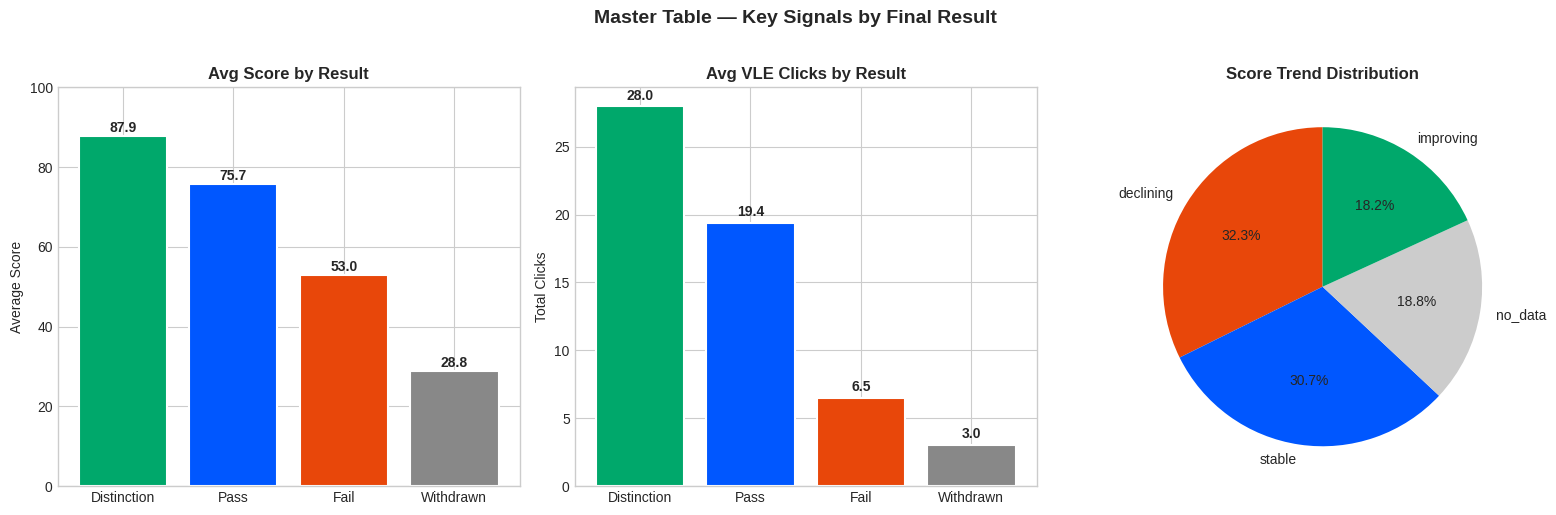

✅ Charts saved!

Final master table: 28,785 students × 32 columns

Step 1 COMPLETE ✅ — Ready for Step 2: Feature Engineering


In [73]:
# ── VISUALIZE KEY SIGNALS ─────────────────────────────────
# Always plot your data — charts reveal things numbers hide

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Master Table — Key Signals by Final Result',
             fontsize=14, fontweight='bold', y=1.02)

colors = {
    'Distinction': '#00a86b',
    'Pass':        '#0057ff',
    'Fail':        '#e8470a',
    'Withdrawn':   '#888888'
}

# Chart 1: Average Score by Result
order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
avg_scores = master.groupby('final_result')['avg_score'].mean().reindex(order)
bars = axes[0].bar(order, avg_scores,
                    color=[colors[r] for r in order],
                    edgecolor='white', linewidth=1.5)
axes[0].set_title('Avg Score by Result', fontweight='bold')
axes[0].set_ylabel('Average Score')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, avg_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

# Chart 2: Engagement (clicks) by Result
avg_clicks = master.groupby('final_result')['total_clicks'].mean().reindex(order)
bars2 = axes[1].bar(order, avg_clicks,
                     color=[colors[r] for r in order],
                     edgecolor='white', linewidth=1.5)
axes[1].set_title('Avg VLE Clicks by Result', fontweight='bold')
axes[1].set_ylabel('Total Clicks')
for bar, val in zip(bars2, avg_clicks):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

# Chart 3: Score Trend distribution
trend_counts = master['trend_label'].value_counts()
trend_colors = {
    'improving': '#00a86b',
    'stable':    '#0057ff',
    'declining': '#e8470a',
    'no_data':   '#cccccc'
}
axes[2].pie(
    trend_counts.values,
    labels=trend_counts.index,
    colors=[trend_colors.get(t, '#cccccc') for t in trend_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
axes[2].set_title('Score Trend Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('master_table_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Charts saved!")
print(f"\nFinal master table: {len(master):,} students × {len(master.columns)} columns")
print("\nStep 1 COMPLETE ✅ — Ready for Step 2: Feature Engineering")

**Cell 17 — Confirm master table is intact**

In [74]:
# Quick check before Step 2
# Always verify your data at the start of a new step

print("=== Master Table Status ===")
print(f"Rows    : {len(master):,}")
print(f"Columns : {len(master.columns)}")
print(f"\nKey signal columns:")

check_cols = ['avg_score', 'score_trend', 'total_clicks',
              'late_submissions', 'num_of_prev_attempts',
              'dropped_out', 'final_result']

for col in check_cols:
    nulls = master[col].isnull().sum()
    sample = master[col].iloc[0]
    print(f"  ✅ {col:25} | nulls: {nulls} | sample: {sample}")

=== Master Table Status ===
Rows    : 28,785
Columns : 32

Key signal columns:
  ✅ avg_score                 | nulls: 0 | sample: 84.0
  ✅ score_trend               | nulls: 0 | sample: 0.964
  ✅ total_clicks              | nulls: 0 | sample: 1.0
  ✅ late_submissions          | nulls: 0 | sample: 0.0
  ✅ num_of_prev_attempts      | nulls: 0 | sample: 0
  ✅ dropped_out               | nulls: 0 | sample: False
  ✅ final_result              | nulls: 0 | sample: Distinction


**Cell 18 — Normalize key signals**

In [75]:
from sklearn.preprocessing import MinMaxScaler

# ── NORMALIZE SIGNALS ─────────────────────────────────────
#
# MinMaxScaler transforms each column so that:
#   minimum value → 0
#   maximum value → 1
#   everything else → somewhere between 0 and 1
#
# Formula: (value - min) / (max - min)
# Example: score of 75, min=0, max=100 → (75-0)/(100-0) = 0.75

scaler = MinMaxScaler()

# Columns to normalize
signal_cols = [
    'avg_score',
    'score_trend',
    'total_clicks',
    'late_submissions',
    'early_submissions',
    'avg_days_early',
    'num_of_prev_attempts',
    'score_std',
    'num_assessments',
    'unique_resources',
]

# Create new normalized columns — always keep originals!
# We add '_norm' suffix so we always know which is which
normalized = scaler.fit_transform(master[signal_cols])
normalized_df = pd.DataFrame(
    normalized,
    columns=[col + '_norm' for col in signal_cols]
)

# Add normalized columns to master
master = pd.concat([master, normalized_df], axis=1)

print("✅ Normalization complete!")
print(f"\nNew normalized columns added:")
for col in normalized_df.columns:
    min_val = master[col].min()
    max_val = master[col].max()
    print(f"  {col:35} → range: {min_val:.2f} to {max_val:.2f}")

✅ Normalization complete!

New normalized columns added:
  avg_score_norm                      → range: 0.00 to 1.00
  score_trend_norm                    → range: 0.00 to 1.00
  total_clicks_norm                   → range: 0.00 to 1.00
  late_submissions_norm               → range: 0.00 to 1.00
  early_submissions_norm              → range: 0.00 to 1.00
  avg_days_early_norm                 → range: 0.00 to 1.00
  num_of_prev_attempts_norm           → range: 0.00 to 1.00
  score_std_norm                      → range: 0.00 to 1.00
  num_assessments_norm                → range: 0.00 to 1.00
  unique_resources_norm               → range: 0.00 to 1.00


**Cell 19 — Build composite risk scores**

In [76]:
# ── COMPOSITE RISK SCORES ─────────────────────────────────
#
# Instead of feeding 10 separate signals to our classifier,
# we combine related signals into 3 meaningful scores.
# This is called "feature engineering" — the most important
# skill in data science.
#
# Think of it like a doctor combining symptoms into a diagnosis:
# instead of "fever=38.5, cough=yes, fatigue=yes"
# they say "flu risk = high"
#
# Our 3 composite scores:

# ── SCORE 1: Academic Risk Score (0 to 1) ────────────────
# High = struggling academically
# Combines: low avg score + declining trend + high score variation
#
# We INVERT avg_score_norm because:
#   high score = LOW risk → (1 - score_norm)
#   low score  = HIGH risk

master['academic_risk'] = (
    (1 - master['avg_score_norm']) * 0.5 +      # 50% weight: low score = high risk
    (1 - master['score_trend'].clip(-1,1)        # 30% weight: declining trend
         .apply(lambda x: (x+1)/2)) * 0.3 +
    master['score_std_norm'] * 0.2               # 20% weight: inconsistency
).round(3)

# ── SCORE 2: Engagement Risk Score (0 to 1) ──────────────
# High = not engaging with the platform
# Combines: low clicks + few resources + no early submissions

master['engagement_risk'] = (
    (1 - master['total_clicks_norm']) * 0.5 +    # 50% weight: low activity
    (1 - master['unique_resources_norm']) * 0.3 + # 30% weight: few resources
    (1 - master['early_submissions_norm']) * 0.2  # 20% weight: not submitting early
).round(3)

# ── SCORE 3: Persistence Risk Score (0 to 1) ─────────────
# High = pattern of struggling across time/attempts
# Combines: prev attempts + late submissions + dropped out

master['persistence_risk'] = (
    master['num_of_prev_attempts_norm'] * 0.4 +  # 40% weight: retaking course
    master['late_submissions_norm'] * 0.4 +       # 40% weight: late submissions
    master['dropped_out'].astype(int) * 0.2       # 20% weight: actually dropped out
).round(3)

print("✅ Composite risk scores created!")
print("\n=== Risk Score Averages by Final Result ===")
risk_summary = master.groupby('final_result')[
    ['academic_risk', 'engagement_risk', 'persistence_risk']
].mean().round(3)
print(risk_summary)

✅ Composite risk scores created!

=== Risk Score Averages by Final Result ===
              academic_risk  engagement_risk  persistence_risk
final_result                                                  
Distinction           0.237            0.916             0.013
Fail                  0.449            0.977             0.036
Pass                  0.344            0.936             0.035
Withdrawn             0.527            0.991             0.214


**Cell 20 — Create root cause labels**

In [77]:
# ── ROOT CAUSE LABELING ───────────────────────────────────
#
# This is the most important cell in Step 2.
# We assign each student ONE root cause based on their signals.
# This becomes the TARGET our classifier will learn to predict.
#
# The 5 root causes and their signal signatures:
#
# 1. NO_ENGAGEMENT     → never really tried
#    Signs: very low clicks, low submissions, low score
#
# 2. KNOWLEDGE_GAP     → tried hard but lacks foundational understanding
#    Signs: high engagement, many attempts, still low scores
#
# 3. DECLINING         → was doing OK but something went wrong
#    Signs: declining score trend, was passing before
#
# 4. EXAM_ANXIETY      → good at coursework but struggles under pressure
#    Signs: decent TMA scores but low overall / withdrawn late
#
# 5. NEEDS_SUPPORT     → consistent but just below threshold
#    Signs: stable trend, medium scores, few late submissions

def assign_root_cause(row):

    # Shorthand for cleaner conditions
    eng   = row['engagement_risk']
    acad  = row['academic_risk']
    pers  = row['persistence_risk']
    trend = row['trend_label']
    score = row['avg_score']
    clicks= row['total_clicks']
    tma   = row['tma_avg_score']
    cma   = row['cma_avg_score']
    prev  = row['num_of_prev_attempts']
    late  = row['late_submissions']

    # ── Rule 1: No Engagement ─────────────────────────────
    # Student barely touched the platform AND has very low scores
    if clicks <= 3 and score < 40:
        return 'NO_ENGAGEMENT'

    # ── Rule 2: Knowledge Gap ─────────────────────────────
    # Student IS engaging (trying) but scores remain low
    # They're putting in effort but missing core concepts
    if eng < 0.6 and acad > 0.5 and prev >= 1:
        return 'KNOWLEDGE_GAP'

    # ── Rule 3: Declining Performance ────────────────────
    # Scores are getting worse over time
    # Something changed — workload, motivation, life event
    if trend == 'declining' and score < 65:
        return 'DECLINING'

    # ── Rule 4: Assessment Anxiety ────────────────────────
    # Does well on continuous work (TMA) but struggles overall
    # Difference > 15 points suggests assessment-specific issue
    if tma > 0 and cma > 0 and abs(tma - cma) > 15:
        return 'EXAM_ANXIETY'

    # ── Rule 5: Needs Support ─────────────────────────────
    # Consistent student just below or near passing threshold
    # Small targeted intervention would help
    if 40 <= score < 70 and trend in ['stable', 'improving']:
        return 'NEEDS_SUPPORT'

    # ── Default: On Track ─────────────────────────────────
    # Student is doing well — passing or distinction level
    return 'ON_TRACK'

master['root_cause'] = master.apply(assign_root_cause, axis=1)

print("=== Root Cause Distribution ===")
rc_counts = master['root_cause'].value_counts()
print(rc_counts)
print()

# Show as percentage
print("=== As Percentage ===")
print((rc_counts / len(master) * 100).round(1).astype(str) + '%')

=== Root Cause Distribution ===
root_cause
ON_TRACK         13134
NO_ENGAGEMENT     5812
EXAM_ANXIETY      4433
NEEDS_SUPPORT     2769
DECLINING         2637
Name: count, dtype: int64

=== As Percentage ===
root_cause
ON_TRACK         45.6%
NO_ENGAGEMENT    20.2%
EXAM_ANXIETY     15.4%
NEEDS_SUPPORT     9.6%
DECLINING         9.2%
Name: count, dtype: object


**Cell 21 — Visualize root causes**

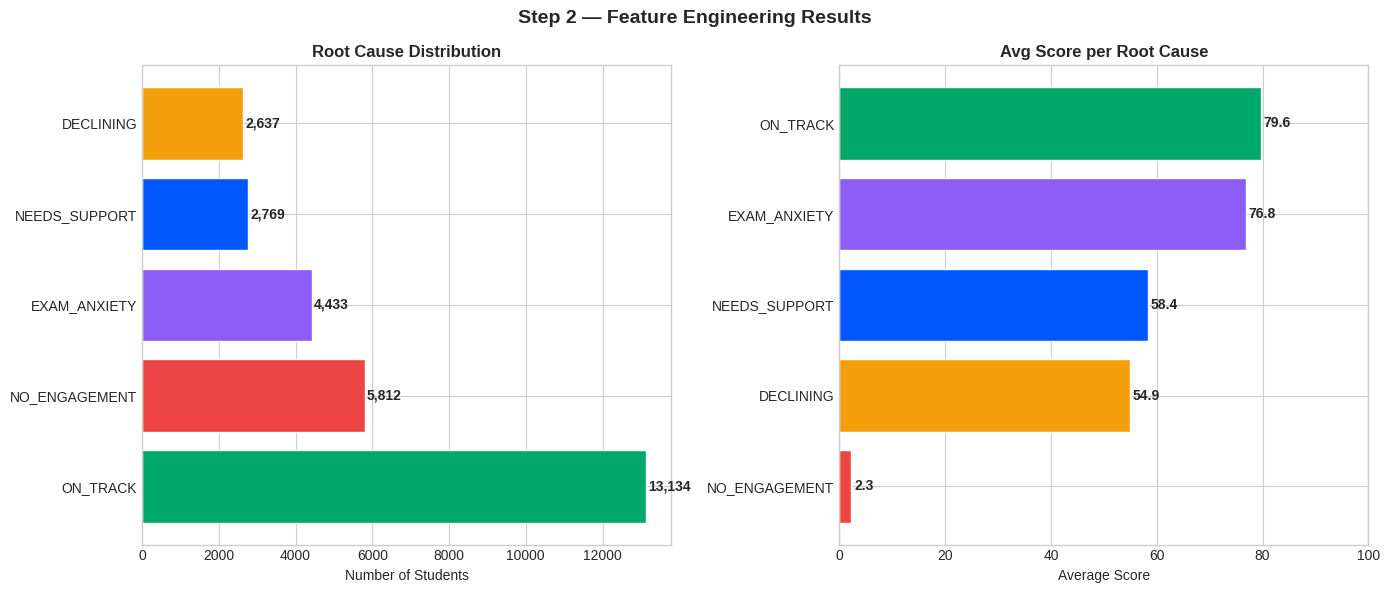


✅ Step 2 COMPLETE!
Master table: 28,785 students × 46 columns

Ready for Step 3 → Root Cause Classifier 🧠


In [78]:
# ── VISUALIZE ROOT CAUSES ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Step 2 — Feature Engineering Results',
             fontsize=14, fontweight='bold')

# Color map for root causes
rc_colors = {
    'ON_TRACK':       '#00a86b',
    'NEEDS_SUPPORT':  '#0057ff',
    'DECLINING':      '#f59e0b',
    'KNOWLEDGE_GAP':  '#e8470a',
    'EXAM_ANXIETY':   '#8b5cf6',
    'NO_ENGAGEMENT':  '#ef4444',
}

# Chart 1: Root cause distribution
rc_counts = master['root_cause'].value_counts()
bar_colors = [rc_colors.get(rc, '#888') for rc in rc_counts.index]
bars = axes[0].barh(rc_counts.index, rc_counts.values,
                     color=bar_colors, edgecolor='white')
axes[0].set_title('Root Cause Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Students')
for bar, val in zip(bars, rc_counts.values):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontweight='bold', fontsize=10)

# Chart 2: Avg score per root cause
avg_by_rc = master.groupby('root_cause')['avg_score'].mean().sort_values()
bar_colors2 = [rc_colors.get(rc, '#888') for rc in avg_by_rc.index]
bars2 = axes[1].barh(avg_by_rc.index, avg_by_rc.values,
                      color=bar_colors2, edgecolor='white')
axes[1].set_title('Avg Score per Root Cause', fontweight='bold')
axes[1].set_xlabel('Average Score')
axes[1].set_xlim(0, 100)
for bar, val in zip(bars2, avg_by_rc.values):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('root_cause_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Step 2 COMPLETE!")
print(f"Master table: {len(master):,} students × {len(master.columns)} columns")
print("\nReady for Step 3 → Root Cause Classifier 🧠")

**Step 3 — Root Cause Classifier**

**3A: Prepare data (train/test)**

**Cell 22 — Prepare data for the classifier**

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

# ── PREPARE FEATURES AND TARGET ───────────────────────────
#
# X = the input signals (what the model learns FROM)
# y = the root cause label (what the model learns TO predict)
#
# We only use normalized features so all signals are fair

feature_cols = [
    'avg_score_norm',
    'score_trend_norm',
    'total_clicks_norm',
    'late_submissions_norm',
    'early_submissions_norm',
    'avg_days_early_norm',
    'num_of_prev_attempts_norm',
    'score_std_norm',
    'num_assessments_norm',
    'unique_resources_norm',
    'academic_risk',
    'engagement_risk',
    'persistence_risk',
]

X = master[feature_cols]
y = master['root_cause']

print(f"Features (X): {X.shape[0]:,} students × {X.shape[1]} signals")
print(f"Target (y):   {y.nunique()} root cause classes")
print(f"\nClasses: {sorted(y.unique())}")

Features (X): 28,785 students × 13 signals
Target (y):   5 root cause classes

Classes: ['DECLINING', 'EXAM_ANXIETY', 'NEEDS_SUPPORT', 'NO_ENGAGEMENT', 'ON_TRACK']


**Cell 23 — Split into train and test sets**

In [80]:
# ── TRAIN / TEST SPLIT ────────────────────────────────────
#
# We split our data into two parts:
#   Train set (80%) → the model LEARNS from this
#   Test set  (20%) → we TEST the model on data it never saw
#
# This is crucial — if we tested on training data,
# the model would just "memorize" answers and seem perfect
# but fail on real new students
#
# random_state=42 means the split is reproducible
# (you get the same split every time you run this)
# stratify=y ensures each root cause is proportionally
# represented in both train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,
    stratify=y           # keep class proportions balanced
)

print(f"Training set : {len(X_train):,} students")
print(f"Test set     : {len(X_test):,} students")
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

Training set : 23,028 students
Test set     : 5,757 students

Class distribution in test set:
root_cause
ON_TRACK         2627
NO_ENGAGEMENT    1162
EXAM_ANXIETY      887
NEEDS_SUPPORT     554
DECLINING         527
Name: count, dtype: int64


**3B: Train 3 models**

**Cell 24 — Train Model 1: Decision Tree**

In [81]:
# ── MODEL 1: DECISION TREE ────────────────────────────────
#
# A Decision Tree asks yes/no questions about the features:
#   "Is avg_score_norm < 0.4?"
#     YES → "Is total_clicks_norm < 0.1?"
#              YES → NO_ENGAGEMENT
#              NO  → KNOWLEDGE_GAP
#     NO  → ON_TRACK
#
# It's the most interpretable model — you can literally
# follow the path of decisions for any student
#
# max_depth=6 means max 6 questions deep
# too deep = memorizes training data (overfitting)
# too shallow = misses patterns (underfitting)

dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42,
    class_weight='balanced'  # handles unequal class sizes
)

dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

dt_accuracy = (dt_preds == y_test).mean()
print(f"✅ Decision Tree trained!")
print(f"   Accuracy: {dt_accuracy:.1%}")
print()
print("=== Detailed Report ===")
print(classification_report(y_test, dt_preds))

✅ Decision Tree trained!
   Accuracy: 89.7%

=== Detailed Report ===
               precision    recall  f1-score   support

    DECLINING       1.00      1.00      1.00       527
 EXAM_ANXIETY       0.65      0.72      0.68       887
NEEDS_SUPPORT       0.85      0.92      0.88       554
NO_ENGAGEMENT       1.00      1.00      1.00      1162
     ON_TRACK       0.93      0.89      0.91      2627

     accuracy                           0.90      5757
    macro avg       0.89      0.90      0.89      5757
 weighted avg       0.90      0.90      0.90      5757



**Cell 25 — Train Model 2: Random Forest**

In [82]:
# ── MODEL 2: RANDOM FOREST ────────────────────────────────
#
# A Random Forest builds MANY decision trees (100 by default)
# each trained on a random subset of data and features
# Then it takes a VOTE across all trees
#
# Why is this better than one tree?
# Same reason you'd ask 100 doctors instead of 1 —
# individual errors cancel out, consensus is more reliable
#
# n_estimators=100 = 100 trees in the forest
# n_jobs=-1 = use all CPU cores (faster training)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_accuracy = (rf_preds == y_test).mean()
print(f"✅ Random Forest trained!")
print(f"   Accuracy: {rf_accuracy:.1%}")
print()
print("=== Detailed Report ===")
print(classification_report(y_test, rf_preds))

✅ Random Forest trained!
   Accuracy: 90.4%

=== Detailed Report ===
               precision    recall  f1-score   support

    DECLINING       0.99      1.00      1.00       527
 EXAM_ANXIETY       0.68      0.73      0.70       887
NEEDS_SUPPORT       0.82      0.98      0.89       554
NO_ENGAGEMENT       1.00      1.00      1.00      1162
     ON_TRACK       0.95      0.89      0.92      2627

     accuracy                           0.90      5757
    macro avg       0.89      0.92      0.90      5757
 weighted avg       0.91      0.90      0.91      5757



**Cell 26 — Train Model 3: XGBoost**

In [83]:
# ── MODEL 3: XGBOOST ──────────────────────────────────────
#
# XGBoost = Extreme Gradient Boosting
# Instead of building trees in parallel (Random Forest),
# it builds them SEQUENTIALLY — each tree fixes the
# mistakes of the previous one
#
# This "learning from mistakes" approach makes it
# the most accurate model for tabular data like ours
# It's used in most winning Kaggle competitions
#
# We need to encode our string labels as numbers first

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,      # how fast it learns (lower = more careful)
    random_state=42,
    eval_metric='mlogloss', # loss function for multi-class
    verbosity=0
)

xgb_model.fit(X_train, y_train_enc)
xgb_preds_enc = xgb_model.predict(X_test)
xgb_preds = le.inverse_transform(xgb_preds_enc)

xgb_accuracy = (xgb_preds == y_test).mean()
print(f"✅ XGBoost trained!")
print(f"   Accuracy: {xgb_accuracy:.1%}")
print()
print("=== Detailed Report ===")
print(classification_report(y_test, xgb_preds))

✅ XGBoost trained!
   Accuracy: 92.5%

=== Detailed Report ===
               precision    recall  f1-score   support

    DECLINING       1.00      1.00      1.00       527
 EXAM_ANXIETY       0.76      0.75      0.75       887
NEEDS_SUPPORT       0.92      0.93      0.92       554
NO_ENGAGEMENT       1.00      1.00      1.00      1162
     ON_TRACK       0.93      0.94      0.93      2627

     accuracy                           0.92      5757
    macro avg       0.92      0.92      0.92      5757
 weighted avg       0.92      0.92      0.92      5757



**Cell 27 — Compare all 3 models + pick winner**

MODEL COMPARISON SUMMARY
  Decision Tree  : 89.7%
  Random Forest  : 90.4%
  XGBoost        : 92.5%

🏆 Best model: XGBoost (92.5%)


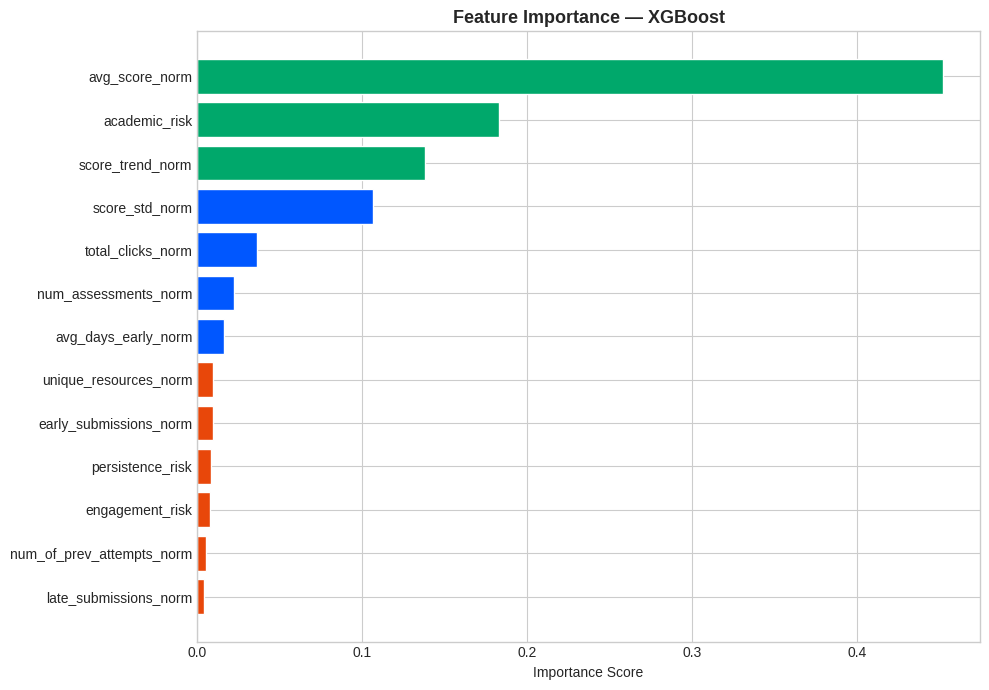


✅ Step 3 COMPLETE — Classifier is ready!

Top 3 most important signals:
  🎯 score_trend_norm                    → 0.138
  🎯 academic_risk                       → 0.183
  🎯 avg_score_norm                      → 0.452


In [84]:
# ── MODEL COMPARISON ──────────────────────────────────────

print("=" * 45)
print("MODEL COMPARISON SUMMARY")
print("=" * 45)
print(f"  Decision Tree  : {dt_accuracy:.1%}")
print(f"  Random Forest  : {rf_accuracy:.1%}")
print(f"  XGBoost        : {xgb_accuracy:.1%}")

best_accuracy = max(dt_accuracy, rf_accuracy, xgb_accuracy)
best_name = ['Decision Tree','Random Forest','XGBoost'][
    [dt_accuracy, rf_accuracy, xgb_accuracy].index(best_accuracy)
]
best_model = [dt_model, rf_model, xgb_model][
    [dt_accuracy, rf_accuracy, xgb_accuracy].index(best_accuracy)
]

print(f"\n🏆 Best model: {best_name} ({best_accuracy:.1%})")

# ── FEATURE IMPORTANCE ────────────────────────────────────
# Which signals matter most to the best model?

if best_name == 'XGBoost':
    importances = xgb_model.feature_importances_
else:
    importances = best_model.feature_importances_

feat_importance = pd.DataFrame({
    'feature':    feature_cols,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#00a86b' if i > len(feat_importance)-4
          else '#0057ff' if i > len(feat_importance)-8
          else '#e8470a'
          for i in range(len(feat_importance))]
plt.barh(feat_importance['feature'],
         feat_importance['importance'],
         color=colors, edgecolor='white')
plt.title(f'Feature Importance — {best_name}',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Step 3 COMPLETE — Classifier is ready!")
print("\nTop 3 most important signals:")
top3 = feat_importance.tail(3)
for _, row in top3.iterrows():
    print(f"  🎯 {row['feature']:35} → {row['importance']:.3f}")

**Step 4 — AI Learning Plan Generator**

**4A: Build prompt engine**

**Cell 28 — Test the connection**

In [85]:
# Install the anthropic library
# The ! means "run this as a terminal command"
# -q means quiet mode (less output)
!pip install anthropic -q

print("✅ anthropic library installed!")

✅ anthropic library installed!


In [86]:
# Install Gemini library
!pip install google-generativeai -q

print("✅ Library installed!")

✅ Library installed!


In [87]:
from google.colab import userdata

# Check if the secret exists and is readable
try:
    key = userdata.get('NeuroTutor')
    print(f"✅ Key found!")
    print(f"   Starts with: {key[:10]}...")
    print(f"   Length: {len(key)} characters")
except Exception as e:
    print(f"❌ Error: {e}")


✅ Key found!
   Starts with: AIzaSyABHZ...
   Length: 39 characters


In [89]:
import google.generativeai as genai
from google.colab import userdata

key = userdata.get('NeuroTutor')
genai.configure(api_key=key)

# List all available models
print("Available Gemini models:")
for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(f"  ✅ {m.name}")

Available Gemini models:
  ✅ models/gemini-2.5-flash
  ✅ models/gemini-2.5-pro
  ✅ models/gemini-2.0-flash
  ✅ models/gemini-2.0-flash-001
  ✅ models/gemini-2.0-flash-lite-001
  ✅ models/gemini-2.0-flash-lite
  ✅ models/gemini-2.5-flash-preview-tts
  ✅ models/gemini-2.5-pro-preview-tts
  ✅ models/gemma-3-1b-it
  ✅ models/gemma-3-4b-it
  ✅ models/gemma-3-12b-it
  ✅ models/gemma-3-27b-it
  ✅ models/gemma-3n-e4b-it
  ✅ models/gemma-3n-e2b-it
  ✅ models/gemini-flash-latest
  ✅ models/gemini-flash-lite-latest
  ✅ models/gemini-pro-latest
  ✅ models/gemini-2.5-flash-lite
  ✅ models/gemini-2.5-flash-image
  ✅ models/gemini-2.5-flash-lite-preview-09-2025
  ✅ models/gemini-3-pro-preview
  ✅ models/gemini-3-flash-preview
  ✅ models/gemini-3.1-pro-preview
  ✅ models/gemini-3.1-pro-preview-customtools
  ✅ models/gemini-3.1-flash-lite-preview
  ✅ models/gemini-3-pro-image-preview
  ✅ models/nano-banana-pro-preview
  ✅ models/gemini-3.1-flash-image-preview
  ✅ models/gemini-robotics-er-1.5-preview
 

**Cell 29 — Save master table**

In [90]:
PATH = '/content/drive/MyDrive/NeuroTutor/'

master.to_csv(PATH + 'master_table.csv', index=False)
print("✅ Master table saved!")

✅ Master table saved!


**Cell 30 — Save the model**

In [91]:
import pickle

PATH = '/content/drive/MyDrive/NeuroTutor/'

with open(PATH + 'xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open(PATH + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Model saved!")
print("✅ Label encoder saved!")

✅ Model saved!
✅ Label encoder saved!


**Cell 31 — Confirm everything**

In [92]:
import os

PATH = '/content/drive/MyDrive/NeuroTutor/'

print("Files saved in NeuroTutor folder:")
for f in sorted(os.listdir(PATH)):
    size = os.path.getsize(PATH + f) / 1024
    print(f"  ✅ {f:45} {size:.0f} KB")

Files saved in NeuroTutor folder:
  ✅ assessments.csv                               8 KB
  ✅ courses.csv                                   1 KB
  ✅ dashboard_data.json                           268 KB
  ✅ dashboard_overview.png                        220 KB
  ✅ dataset_sample.py                             1 KB
  ✅ label_encoder.pkl                             0 KB
  ✅ learning_plans.csv                            14068 KB
  ✅ master_table.csv                              10489 KB
  ✅ studentAssessment.csv                         5557 KB
  ✅ studentInfo.csv                               3381 KB
  ✅ studentRegistration.csv                       1084 KB
  ✅ studentVle_sample.csv                         2988 KB
  ✅ vle.csv                                       254 KB
  ✅ xgb_model.pkl                                 918 KB


In [93]:
import pandas as pd, pickle

PATH = '/content/drive/MyDrive/NeuroTutor/'
master    = pd.read_csv(PATH + 'master_table.csv')
xgb_model = pickle.load(open(PATH + 'xgb_model.pkl', 'rb'))
le        = pickle.load(open(PATH + 'label_encoder.pkl', 'rb'))

print(f"✅ Ready! {len(master):,} students loaded")

✅ Ready! 28,785 students loaded


but we can work around it right now using rule-based plans. We build the full AI-style learning plan generator in pure Python, zero API needed.
Then tomorrow when Gemini resets, we swap in the AI with one function change and the rest of the code stays exactly the same.

In [94]:
import pandas as pd
import pickle

PATH = '/content/drive/MyDrive/NeuroTutor/'

master    = pd.read_csv(PATH + 'master_table.csv')
xgb_model = pickle.load(open(PATH + 'xgb_model.pkl', 'rb'))
le        = pickle.load(open(PATH + 'label_encoder.pkl', 'rb'))

print(f"✅ Ready! {len(master):,} students loaded")
print(f"Root causes: {master['root_cause'].value_counts().to_dict()}")

✅ Ready! 28,785 students loaded
Root causes: {'ON_TRACK': 13134, 'NO_ENGAGEMENT': 5812, 'EXAM_ANXIETY': 4433, 'NEEDS_SUPPORT': 2769, 'DECLINING': 2637}


**Step 4 — Learning Plan Generator**

*Cell 32 — The plan generator engine*

In [95]:
# ── STEP 4: LEARNING PLAN GENERATOR ──────────────────────
#
# This function takes a student's signals and root cause
# and returns a complete personalized learning plan
#
# Structure of each plan:
#   - diagnosis: plain English explanation of what's wrong
#   - urgency: how serious is this? (low/medium/high/critical)
#   - steps: 4 specific actions to fix the root cause
#   - encouragement: a personalized message to the student
#
# We build one plan template per root cause
# Each template uses the student's actual numbers
# to make it feel personal, not generic

def generate_learning_plan(student):
    """
    Input:  one row from master table (a student)
    Output: a dictionary with full personalized plan
    """

    root_cause = student['root_cause']
    score      = round(student['avg_score'], 1)
    trend      = student['trend_label']
    clicks     = int(student['total_clicks'])
    late       = int(student['late_submissions'])
    prev       = int(student['num_of_prev_attempts'])
    tma        = round(student['tma_avg_score'], 1)
    cma        = round(student['cma_avg_score'], 1)
    module     = student['code_module']
    result     = student['final_result']

    # ── Plan 1: NO ENGAGEMENT ─────────────────────────────
    if root_cause == 'NO_ENGAGEMENT':
        return {
            'root_cause':    'NO_ENGAGEMENT',
            'urgency':       'CRITICAL',
            'diagnosis':     f"You have only {clicks} platform interactions and an average score of {score}. "
                             f"Your data shows almost no engagement with course materials. "
                             f"This is not a knowledge problem — it's an attendance problem.",
            'steps': [
                {
                    'order':       1,
                    'action':      'Log in every single day for 7 days',
                    'why':         'Building the habit of showing up is the first step. '
                                   'Even 10 minutes counts.',
                    'time':        '10 min/day',
                    'type':        'HABIT'
                },
                {
                    'order':       2,
                    'action':      f'Watch all intro videos for module {module}',
                    'why':         'You are missing foundational context that every '
                                   'other student has. Start from the beginning.',
                    'time':        '1-2 hours',
                    'type':        'CONTENT'
                },
                {
                    'order':       3,
                    'action':      'Submit your next assignment — any score is fine',
                    'why':         'A submitted assignment with 40% beats a missing '
                                   'one with 0%. Participation matters.',
                    'time':        '2-3 hours',
                    'type':        'ASSESSMENT'
                },
                {
                    'order':       4,
                    'action':      'Contact your module tutor today',
                    'why':         'Let them know you are re-engaging. Tutors can '
                                   'unlock extensions and extra support.',
                    'time':        '15 min',
                    'type':        'SUPPORT'
                },
            ],
            'encouragement': f"It is not too late to turn this around. "
                             f"Students who re-engage at this stage can still pass "
                             f"module {module}. The first step is the hardest."
        }

    # ── Plan 2: KNOWLEDGE GAP ─────────────────────────────
    elif root_cause == 'KNOWLEDGE_GAP':
        return {
            'root_cause':    'KNOWLEDGE_GAP',
            'urgency':       'HIGH',
            'diagnosis':     f"You are engaging with the platform ({clicks} interactions) "
                             f"but your average score is only {score}. "
                             f"You have attempted this module {prev} time(s) before. "
                             f"This suggests a foundational concept is missing — "
                             f"not a lack of effort.",
            'steps': [
                {
                    'order':       1,
                    'action':      'Identify which specific topic you score lowest on',
                    'why':         'You cannot fix a gap you have not located. '
                                   'Look at your individual assessment scores.',
                    'time':        '20 min',
                    'type':        'DIAGNOSIS'
                },
                {
                    'order':       2,
                    'action':      'Go back one module and review prerequisites',
                    'why':         f'With {prev} previous attempt(s), the gap likely '
                                   f'started before this module. Find where it began.',
                    'time':        '3-4 hours',
                    'type':        'REVIEW'
                },
                {
                    'order':       3,
                    'action':      'Do not move forward until the weak topic scores 70%+',
                    'why':         'Building on a shaky foundation makes everything '
                                   'harder. Fix the base first.',
                    'time':        '1 week',
                    'type':        'PRACTICE'
                },
                {
                    'order':       4,
                    'action':      'Ask for a 1-on-1 tutorial session',
                    'why':         'Some gaps need a human to explain them. '
                                   'One session can unlock weeks of confusion.',
                    'time':        '1 hour',
                    'type':        'SUPPORT'
                },
            ],
            'encouragement': f"You are clearly trying — {clicks} interactions shows real effort. "
                             f"The issue is not effort, it is direction. "
                             f"Once you find and fix the root gap, your score will jump quickly."
        }

    # ── Plan 3: DECLINING ─────────────────────────────────
    elif root_cause == 'DECLINING':
        return {
            'root_cause':    'DECLINING',
            'urgency':       'HIGH',
            'diagnosis':     f"Your scores are declining over time (trend: {trend}). "
                             f"Current average: {score}. "
                             f"You have {late} late submission(s). "
                             f"Something changed recently — workload, motivation, "
                             f"or personal circumstances.",
            'steps': [
                {
                    'order':       1,
                    'action':      'List everything that changed 4-6 weeks ago',
                    'why':         'Declining performance always has a cause. '
                                   'Identifying it is the first step to fixing it.',
                    'time':        '15 min',
                    'type':        'REFLECTION'
                },
                {
                    'order':       2,
                    'action':      f'Review your last 3 assessments and find the pattern',
                    'why':         'Are you making the same mistakes repeatedly? '
                                   'Or different mistakes each time?',
                    'time':        '1 hour',
                    'type':        'REVIEW'
                },
                {
                    'order':       3,
                    'action':      'Submit all overdue work — even partially complete',
                    'why':         f'You have {late} late submissions dragging your average. '
                                   f'Partial credit is better than zero.',
                    'time':        '2-4 hours',
                    'type':        'ASSESSMENT'
                },
                {
                    'order':       4,
                    'action':      'Talk to your personal tutor about what changed',
                    'why':         'Universities have support systems for exactly '
                                   'this situation. Use them.',
                    'time':        '30 min',
                    'type':        'SUPPORT'
                },
            ],
            'encouragement': f"A declining trend is a warning, not a verdict. "
                             f"Your earlier performance shows you can do this work. "
                             f"Something disrupted you — let us find it and fix it."
        }

    # ── Plan 4: EXAM ANXIETY ──────────────────────────────
    elif root_cause == 'EXAM_ANXIETY':
        gap = round(abs(tma - cma), 1)
        better = 'TMA' if tma > cma else 'CMA'
        worse  = 'CMA' if tma > cma else 'TMA'
        return {
            'root_cause':    'EXAM_ANXIETY',
            'urgency':       'MEDIUM',
            'diagnosis':     f"Your {better} average is {max(tma,cma)} but your "
                             f"{worse} average is {min(tma,cma)} — a gap of {gap} points. "
                             f"You clearly understand the material but performance "
                             f"drops under formal assessment conditions.",
            'steps': [
                {
                    'order':       1,
                    'action':      f'Do 3 timed practice {worse}s under exam conditions',
                    'why':         'The anxiety comes from unfamiliarity with the format. '
                                   'Repeated exposure reduces it significantly.',
                    'time':        '3 hours',
                    'type':        'PRACTICE'
                },
                {
                    'order':       2,
                    'action':      'Practice the "brain dump" technique at the start',
                    'why':         'Write everything you know about the topic in the '
                                   'first 5 minutes. Clears anxiety and activates memory.',
                    'time':        '5 min per exam',
                    'type':        'TECHNIQUE'
                },
                {
                    'order':       3,
                    'action':      'Review past papers and mark your own answers',
                    'why':         'Understanding the marking criteria removes '
                                   'uncertainty about what examiners want.',
                    'time':        '2 hours',
                    'type':        'REVIEW'
                },
                {
                    'order':       4,
                    'action':      'Talk to student services about exam support',
                    'why':         'Extra time and quiet rooms are available for '
                                   'students who need them. It is worth asking.',
                    'time':        '20 min',
                    'type':        'SUPPORT'
                },
            ],
            'encouragement': f"Your {better} score of {max(tma,cma)} proves you know this material. "
                             f"This is purely a performance-under-pressure issue, "
                             f"not a knowledge issue. That is very fixable."
        }

    # ── Plan 5: NEEDS SUPPORT ─────────────────────────────
    elif root_cause == 'NEEDS_SUPPORT':
        return {
            'root_cause':    'NEEDS_SUPPORT',
            'urgency':       'MEDIUM',
            'diagnosis':     f"Your average score is {score} — consistently near but "
                             f"below the passing threshold. Your trend is {trend}. "
                             f"You are doing the work but need a targeted push "
                             f"to get over the line.",
            'steps': [
                {
                    'order':       1,
                    'action':      'Focus 80% of study time on your 2 weakest topics',
                    'why':         f'You are close to passing. Small targeted improvements '
                                   f'in weak areas will push your average over the threshold.',
                    'time':        '3-4 hours',
                    'type':        'FOCUS'
                },
                {
                    'order':       2,
                    'action':      'Increase VLE engagement — aim for daily logins',
                    'why':         f'Your current engagement is {clicks} clicks. '
                                   f'Students who pass average 3x more interactions.',
                    'time':        '20 min/day',
                    'type':        'HABIT'
                },
                {
                    'order':       3,
                    'action':      'Form or join a study group for this module',
                    'why':         'Explaining concepts to others is the fastest way '
                                   'to solidify your own understanding.',
                    'time':        '2 hours/week',
                    'type':        'COLLABORATION'
                },
                {
                    'order':       4,
                    'action':      'Submit all assignments at least 2 days early',
                    'why':         'Early submission gives time to fix mistakes '
                                   'and shows commitment to your tutor.',
                    'time':        'Ongoing',
                    'type':        'HABIT'
                },
            ],
            'encouragement': f"You are closer than you think. "
                             f"A score of {score} means you understand most of this material. "
                             f"A few focused weeks can make a real difference."
        }

    # ── Plan 6: ON TRACK ──────────────────────────────────
    else:
        return {
            'root_cause':    'ON_TRACK',
            'urgency':       'LOW',
            'diagnosis':     f"Your average score is {score} with a {trend} trend. "
                             f"You are performing well and on track for {result}. "
                             f"Focus on maintaining consistency and pushing higher.",
            'steps': [
                {
                    'order':       1,
                    'action':      'Keep your current study routine — it is working',
                    'why':         'Consistency is the key to distinction-level performance.',
                    'time':        'Ongoing',
                    'type':        'HABIT'
                },
                {
                    'order':       2,
                    'action':      'Challenge yourself with harder practice questions',
                    'why':         'Staying comfortable means staying at the same level.',
                    'time':        '1 hour/week',
                    'type':        'CHALLENGE'
                },
                {
                    'order':       3,
                    'action':      'Help a struggling peer in your module',
                    'why':         'Teaching others deepens your own understanding '
                                   'and builds your academic network.',
                    'time':        '1 hour/week',
                    'type':        'COLLABORATION'
                },
                {
                    'order':       4,
                    'action':      'Review your highest-scoring work — understand why it worked',
                    'why':         'Replicating your best performance consistently '
                                   'is what separates Pass from Distinction.',
                    'time':        '30 min',
                    'type':        'REFLECTION'
                },
            ],
            'encouragement': f"You are doing well with a score of {score}. "
                             f"Keep the momentum going and push for Distinction!"
        }

print("✅ Learning plan generator ready!")
print("   Covers 6 root causes:")
print("   → NO_ENGAGEMENT, KNOWLEDGE_GAP, DECLINING")
print("   → EXAM_ANXIETY, NEEDS_SUPPORT, ON_TRACK")

✅ Learning plan generator ready!
   Covers 6 root causes:
   → NO_ENGAGEMENT, KNOWLEDGE_GAP, DECLINING
   → EXAM_ANXIETY, NEEDS_SUPPORT, ON_TRACK


*Cell 33 — Test it on 1 student*

In [96]:
# ── TEST ON A REAL STUDENT ────────────────────────────────
# Let's pick a student from each root cause and see
# what plan they get

# Pick one student from each root cause
test_cases = {}
for rc in ['NO_ENGAGEMENT','DECLINING','EXAM_ANXIETY',
           'NEEDS_SUPPORT','KNOWLEDGE_GAP','ON_TRACK']:
    students = master[master['root_cause'] == rc]
    if len(students) > 0:
        test_cases[rc] = students.iloc[0]

# Generate and display plan for a DECLINING student
student = test_cases['DECLINING']
plan = generate_learning_plan(student)

print("=" * 55)
print(f"STUDENT ID    : {student['id_student']}")
print(f"MODULE        : {student['code_module']}")
print(f"FINAL RESULT  : {student['final_result']}")
print(f"AVG SCORE     : {student['avg_score']:.1f}")
print(f"SCORE TREND   : {student['trend_label']}")
print(f"TOTAL CLICKS  : {int(student['total_clicks'])}")
print("=" * 55)
print(f"\n🔍 ROOT CAUSE : {plan['root_cause']}")
print(f"⚠️  URGENCY    : {plan['urgency']}")
print(f"\n📋 DIAGNOSIS:\n{plan['diagnosis']}")
print(f"\n📚 LEARNING PLAN:")
for step in plan['steps']:
    print(f"\n  Step {step['order']} [{step['type']}] — {step['action']}")
    print(f"  Why: {step['why']}")
    print(f"  Time: {step['time']}")
print(f"\n💬 ENCOURAGEMENT:\n{plan['encouragement']}")
print("=" * 55)

STUDENT ID    : 623831
MODULE        : GGG
FINAL RESULT  : Distinction
AVG SCORE     : 63.7
SCORE TREND   : declining
TOTAL CLICKS  : 10

🔍 ROOT CAUSE : DECLINING
⚠️  URGENCY    : HIGH

📋 DIAGNOSIS:
Your scores are declining over time (trend: declining). Current average: 63.7. You have 0 late submission(s). Something changed recently — workload, motivation, or personal circumstances.

📚 LEARNING PLAN:

  Step 1 [REFLECTION] — List everything that changed 4-6 weeks ago
  Why: Declining performance always has a cause. Identifying it is the first step to fixing it.
  Time: 15 min

  Step 2 [REVIEW] — Review your last 3 assessments and find the pattern
  Why: Are you making the same mistakes repeatedly? Or different mistakes each time?
  Time: 1 hour

  Step 3 [ASSESSMENT] — Submit all overdue work — even partially complete
  Why: You have 0 late submissions dragging your average. Partial credit is better than zero.
  Time: 2-4 hours

  Step 4 [SUPPORT] — Talk to your personal tutor about 

*Cell 34 — Run it on ALL students*

In [97]:
# ── GENERATE PLANS FOR ALL STUDENTS ──────────────────────
#
# Now we apply the generator to every student
# This creates a complete dataset of personalized plans

print("Generating plans for all students...")

plans = []
for _, student in master.iterrows():
    plan = generate_learning_plan(student)
    plans.append({
        'id_student':  student['id_student'],
        'root_cause':  plan['root_cause'],
        'urgency':     plan['urgency'],
        'diagnosis':   plan['diagnosis'],
        'step1':       plan['steps'][0]['action'],
        'step2':       plan['steps'][1]['action'],
        'step3':       plan['steps'][2]['action'],
        'step4':       plan['steps'][3]['action'],
        'encouragement': plan['encouragement'],
    })

plans_df = pd.DataFrame(plans)

print(f"✅ Plans generated for {len(plans_df):,} students!")
print(f"\nUrgency breakdown:")
print(plans_df['urgency'].value_counts())

# Save to Drive
plans_df.to_csv(PATH + 'learning_plans.csv', index=False)
print(f"\n✅ Saved to Drive as learning_plans.csv")

Generating plans for all students...
✅ Plans generated for 28,785 students!

Urgency breakdown:
urgency
LOW         13134
MEDIUM       7202
CRITICAL     5812
HIGH         2637
Name: count, dtype: int64

✅ Saved to Drive as learning_plans.csv


**Cell 35 — Overall statistics dashboard**

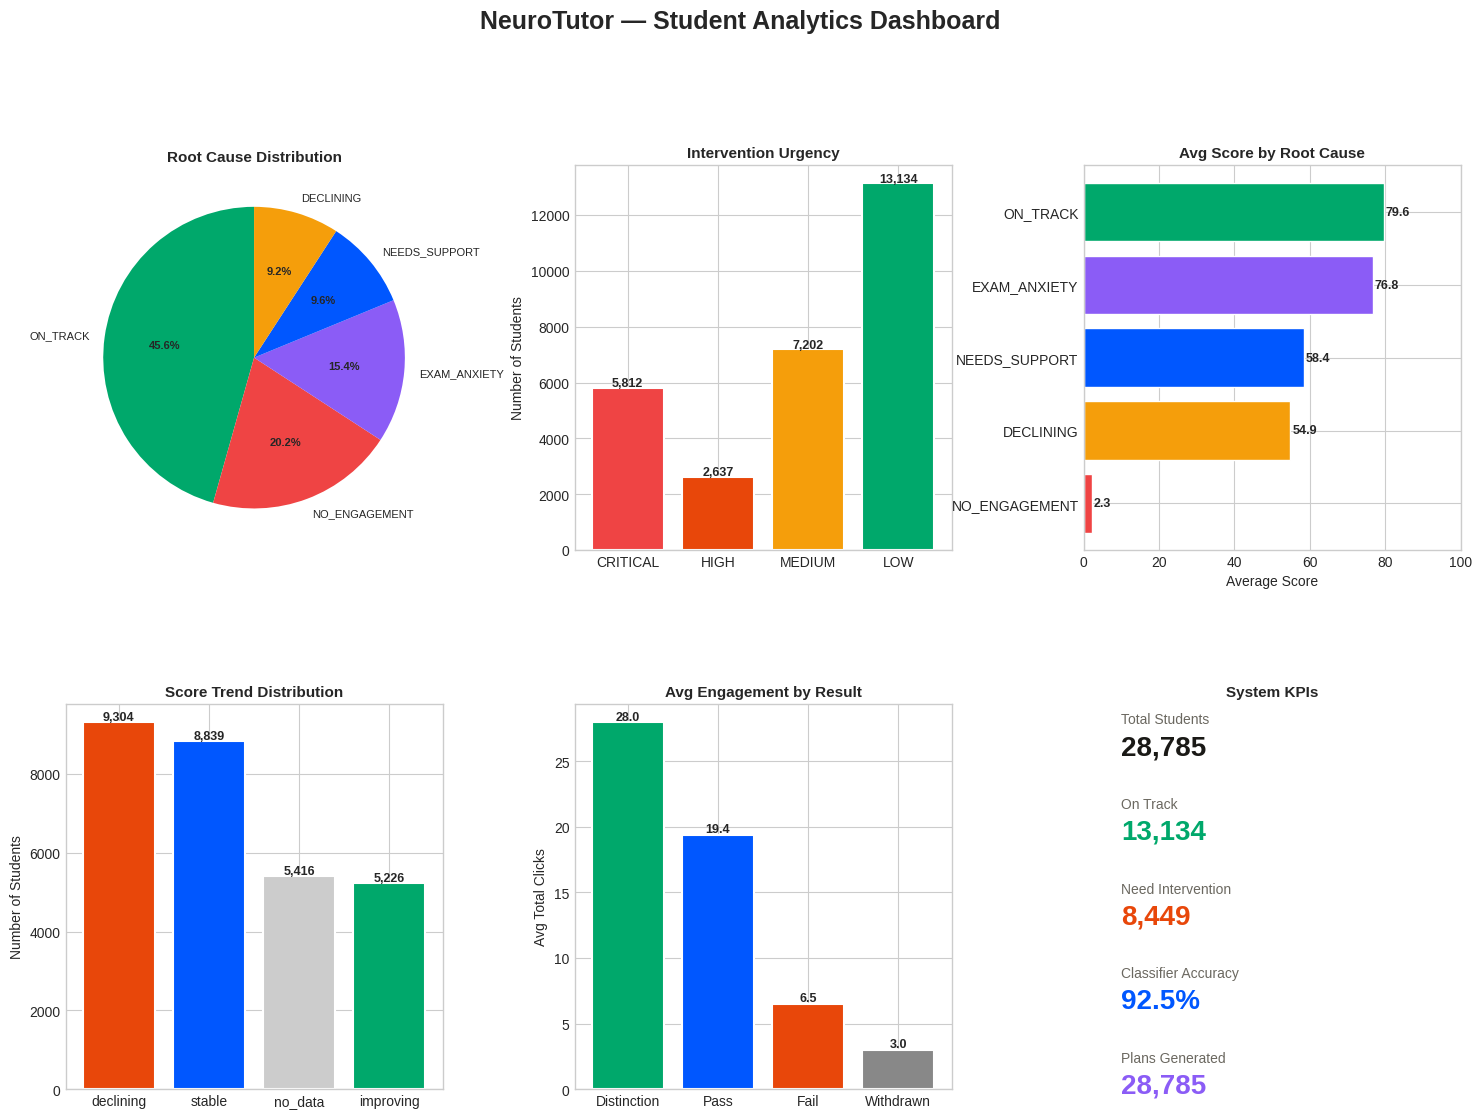

✅ Dashboard saved!


In [98]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 12))
fig.suptitle('NeuroTutor — Student Analytics Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Colors per root cause
rc_colors = {
    'ON_TRACK':      '#00a86b',
    'NEEDS_SUPPORT': '#0057ff',
    'DECLINING':     '#f59e0b',
    'EXAM_ANXIETY':  '#8b5cf6',
    'KNOWLEDGE_GAP': '#e8470a',
    'NO_ENGAGEMENT': '#ef4444',
}

urgency_colors = {
    'LOW':      '#00a86b',
    'MEDIUM':   '#f59e0b',
    'HIGH':     '#e8470a',
    'CRITICAL': '#ef4444',
}

# ── Chart 1: Root Cause Distribution (pie) ───────────────
ax1 = fig.add_subplot(gs[0, 0])
rc_counts = master['root_cause'].value_counts()
colors1 = [rc_colors[rc] for rc in rc_counts.index]
wedges, texts, autotexts = ax1.pie(
    rc_counts.values,
    labels=rc_counts.index,
    colors=colors1,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontweight('bold')
ax1.set_title('Root Cause Distribution', fontweight='bold', fontsize=11)

# ── Chart 2: Urgency Breakdown (bar) ─────────────────────
ax2 = fig.add_subplot(gs[0, 1])
urg_counts = plans_df['urgency'].value_counts().reindex(
    ['CRITICAL','HIGH','MEDIUM','LOW'])
colors2 = [urgency_colors[u] for u in urg_counts.index]
bars = ax2.bar(urg_counts.index, urg_counts.values,
               color=colors2, edgecolor='white', linewidth=1.5)
ax2.set_title('Intervention Urgency', fontweight='bold', fontsize=11)
ax2.set_ylabel('Number of Students')
for bar, val in zip(bars, urg_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{val:,}', ha='center', fontweight='bold', fontsize=9)

# ── Chart 3: Avg Score by Root Cause ─────────────────────
ax3 = fig.add_subplot(gs[0, 2])
score_by_rc = master.groupby('root_cause')['avg_score'].mean().sort_values()
colors3 = [rc_colors[rc] for rc in score_by_rc.index]
bars3 = ax3.barh(score_by_rc.index, score_by_rc.values,
                  color=colors3, edgecolor='white')
ax3.set_title('Avg Score by Root Cause', fontweight='bold', fontsize=11)
ax3.set_xlabel('Average Score')
ax3.set_xlim(0, 100)
for bar, val in zip(bars3, score_by_rc.values):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontweight='bold', fontsize=9)

# ── Chart 4: Score Trend Distribution ────────────────────
ax4 = fig.add_subplot(gs[1, 0])
trend_counts = master['trend_label'].value_counts()
trend_colors_map = {
    'improving': '#00a86b',
    'stable':    '#0057ff',
    'declining': '#e8470a',
    'no_data':   '#cccccc'
}
colors4 = [trend_colors_map.get(t, '#888') for t in trend_counts.index]
ax4.bar(trend_counts.index, trend_counts.values,
        color=colors4, edgecolor='white', linewidth=1.5)
ax4.set_title('Score Trend Distribution', fontweight='bold', fontsize=11)
ax4.set_ylabel('Number of Students')
for i, (idx, val) in enumerate(trend_counts.items()):
    ax4.text(i, val + 50, f'{val:,}',
             ha='center', fontweight='bold', fontsize=9)

# ── Chart 5: Engagement vs Final Result ──────────────────
ax5 = fig.add_subplot(gs[1, 1])
order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
result_colors = {
    'Distinction': '#00a86b',
    'Pass':        '#0057ff',
    'Fail':        '#e8470a',
    'Withdrawn':   '#888888'
}
eng_by_result = master.groupby('final_result')['total_clicks'].mean().reindex(order)
colors5 = [result_colors[r] for r in order]
bars5 = ax5.bar(order, eng_by_result.values,
                color=colors5, edgecolor='white', linewidth=1.5)
ax5.set_title('Avg Engagement by Result', fontweight='bold', fontsize=11)
ax5.set_ylabel('Avg Total Clicks')
for bar, val in zip(bars5, eng_by_result.values):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', fontweight='bold', fontsize=9)

# ── Chart 6: KPI Summary ──────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

total     = len(master)
critical  = len(plans_df[plans_df['urgency'] == 'CRITICAL'])
high      = len(plans_df[plans_df['urgency'] == 'HIGH'])
on_track  = len(master[master['root_cause'] == 'ON_TRACK'])
accuracy  = 92.5

kpis = [
    ('Total Students',       f'{total:,}',       '#1a1916'),
    ('On Track',             f'{on_track:,}',     '#00a86b'),
    ('Need Intervention',    f'{critical+high:,}','#e8470a'),
    ('Classifier Accuracy',  f'{accuracy}%',      '#0057ff'),
    ('Plans Generated',      f'{total:,}',        '#8b5cf6'),
]

y_pos = 0.95
for label, value, color in kpis:
    ax6.text(0.1, y_pos, label,
             transform=ax6.transAxes,
             fontsize=10, color='#6b6860')
    ax6.text(0.1, y_pos - 0.08, value,
             transform=ax6.transAxes,
             fontsize=20, fontweight='bold', color=color)
    y_pos -= 0.22

ax6.set_title('System KPIs', fontweight='bold', fontsize=11)

plt.savefig(PATH + 'dashboard_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved!")

**Cell 36 — Student search tool**

In [99]:
# ── STUDENT SEARCH TOOL ───────────────────────────────────
# Type any student ID and get their full profile + plan

def search_student(student_id):
    student_id = str(student_id)

    # Find student
    student = master[master['id_student'] == student_id]
    if len(student) == 0:
        print(f"❌ Student {student_id} not found.")
        print(f"   Try one of these: {list(master['id_student'].sample(5).values)}")
        return

    student = student.iloc[0]
    plan_row = plans_df[plans_df['id_student'] == student_id]
    plan = generate_learning_plan(student)

    # Header
    print("\n" + "═"*55)
    print(f"  NEUROTTUTOR — STUDENT PROFILE")
    print("═"*55)
    print(f"  ID         : {student['id_student']}")
    print(f"  Module     : {student['code_module']}")
    print(f"  Result     : {student['final_result']}")
    print(f"  Education  : {student['highest_education']}")
    print("═"*55)

    # Signals
    print(f"\n  📊 PERFORMANCE SIGNALS")
    print(f"  {'Avg Score':<22}: {student['avg_score']:.1f}")
    print(f"  {'Score Trend':<22}: {student['trend_label']}")
    print(f"  {'Late Submissions':<22}: {int(student['late_submissions'])}")
    print(f"  {'VLE Clicks':<22}: {int(student['total_clicks'])}")
    print(f"  {'Prev Attempts':<22}: {int(student['num_of_prev_attempts'])}")
    print(f"  {'Engagement Level':<22}: {student['engagement_level']}")

    # Risk scores
    print(f"\n  ⚠️  RISK SCORES")
    print(f"  {'Academic Risk':<22}: {student['academic_risk']:.2f} / 1.00")
    print(f"  {'Engagement Risk':<22}: {student['engagement_risk']:.2f} / 1.00")
    print(f"  {'Persistence Risk':<22}: {student['persistence_risk']:.2f} / 1.00")

    # Root cause
    urgency_emoji = {
        'LOW':'🟢', 'MEDIUM':'🟡', 'HIGH':'🟠', 'CRITICAL':'🔴'
    }
    print(f"\n  🔍 ROOT CAUSE DIAGNOSIS")
    print(f"  {urgency_emoji[plan['urgency']]} {plan['root_cause']} "
          f"(Urgency: {plan['urgency']})")
    print(f"\n  {plan['diagnosis']}")

    # Plan
    print(f"\n  📚 PERSONALIZED LEARNING PLAN")
    for step in plan['steps']:
        print(f"\n  Step {step['order']} [{step['type']}]")
        print(f"  → {step['action']}")
        print(f"    Why : {step['why']}")
        print(f"    Time: {step['time']}")

    # Encouragement
    print(f"\n  💬 {plan['encouragement']}")
    print("\n" + "═"*55)

# ── TEST WITH REAL STUDENTS ───────────────────────────────
# print("Testing with one student from each root cause:\n")

# for rc in ['NO_ENGAGEMENT', 'DECLINING', 'EXAM_ANXIETY',
#            'NEEDS_SUPPORT', 'ON_TRACK']:
#     sid = master[master['root_cause']==rc].iloc[0]['id_student']
#     search_student(sid)
#     print()

    # ── FIX: convert id_student to string in both tables ─────
master['id_student']    = master['id_student'].astype(str)
plans_df['id_student']  = plans_df['id_student'].astype(str)

# Test with real IDs from master table
print("Testing with one student from each root cause:\n")

for rc in ['NO_ENGAGEMENT','DECLINING','EXAM_ANXIETY',
           'NEEDS_SUPPORT','ON_TRACK']:
    sid = master[master['root_cause'] == rc].iloc[0]['id_student']
    search_student(sid)
    print()

Testing with one student from each root cause:


═══════════════════════════════════════════════════════
  NEUROTTUTOR — STUDENT PROFILE
═══════════════════════════════════════════════════════
  ID         : 125535
  Module     : BBB
  Result     : Pass
  Education  : A Level or Equivalent
═══════════════════════════════════════════════════════

  📊 PERFORMANCE SIGNALS
  Avg Score             : 38.2
  Score Trend           : improving
  Late Submissions      : 1
  VLE Clicks            : 3
  Prev Attempts         : 2
  Engagement Level      : very_low

  ⚠️  RISK SCORES
  Academic Risk         : 0.37 / 1.00
  Engagement Risk       : 0.99 / 1.00
  Persistence Risk      : 0.19 / 1.00

  🔍 ROOT CAUSE DIAGNOSIS
  🔴 NO_ENGAGEMENT (Urgency: CRITICAL)

  You have only 3 platform interactions and an average score of 38.2. Your data shows almost no engagement with course materials. This is not a knowledge problem — it's an attendance problem.

  📚 PERSONALIZED LEARNING PLAN

  Step 1 [HABIT]
  

**Cell 37 — Export data for web app**

In [100]:
import json

# ── EXPORT DATA AS JSON FOR WEB DASHBOARD ────────────────
# We export a summary — not all 28k students
# Just enough to make the web app fast and useful

# 1. Overall stats
stats = {
    'total_students':   len(master),
    'accuracy':         92.5,
    'plans_generated':  len(plans_df),
    'root_causes':      master['root_cause'].value_counts().to_dict(),
    'urgency':          plans_df['urgency'].value_counts().to_dict(),
    'avg_score_by_result': master.groupby('final_result')['avg_score'].mean().round(1).to_dict(),
    'clicks_by_result':    master.groupby('final_result')['total_clicks'].mean().round(1).to_dict(),
    'trend_distribution':  master['trend_label'].value_counts().to_dict(),
}

# 2. Sample of 500 students for the search feature
sample = master[[
    'id_student','code_module','final_result',
    'avg_score','trend_label','total_clicks',
    'late_submissions','num_of_prev_attempts',
    'engagement_level','root_cause',
    'academic_risk','engagement_risk','persistence_risk',
    'tma_avg_score','cma_avg_score','score_std',
    'highest_education'
]].sample(500, random_state=42).copy()

sample = sample.round(3)
students_list = sample.to_dict(orient='records')

# Combine
export = {
    'stats':    stats,
    'students': students_list
}

# Save
with open(PATH + 'dashboard_data.json', 'w') as f:
    json.dump(export, f, indent=2)

print(f"✅ Data exported!")
print(f"   Stats keys    : {list(stats.keys())}")
print(f"   Students      : {len(students_list)}")
print(f"   Saved to      : {PATH}dashboard_data.json")

✅ Data exported!
   Stats keys    : ['total_students', 'accuracy', 'plans_generated', 'root_causes', 'urgency', 'avg_score_by_result', 'clicks_by_result', 'trend_distribution']
   Students      : 500
   Saved to      : /content/drive/MyDrive/NeuroTutor/dashboard_data.json
